In [1]:
import sys
print(sys.executable)

/mnt/c/Users/ssait/Desktop/learnings/python-practice-jupyter/venv/bin/python


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [6]:
df = pd.read_csv("/mnt/c/Users/ssait/Downloads/boston.csv")

In [8]:
df.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [10]:
df.shape

(506, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


Exploratory Data Analysis

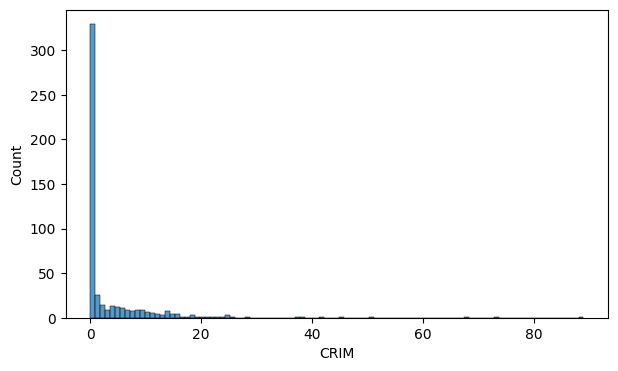

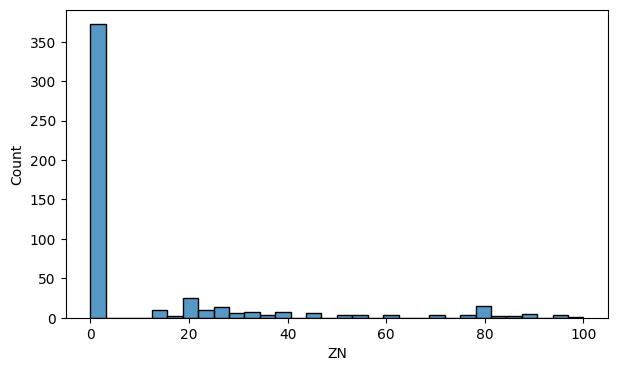

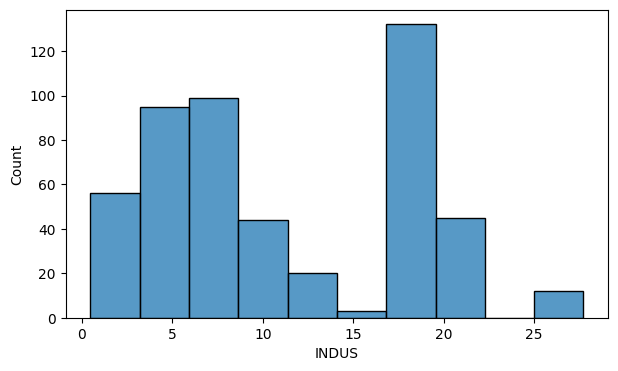

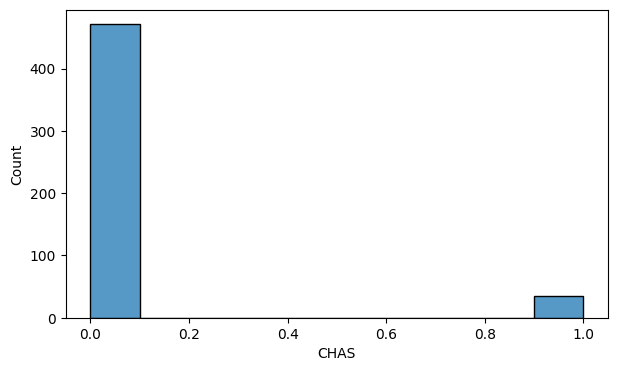

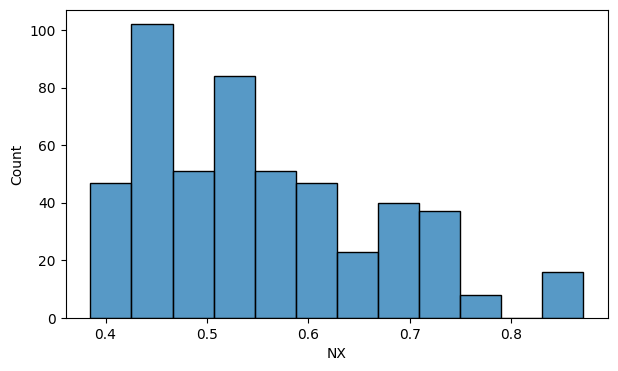

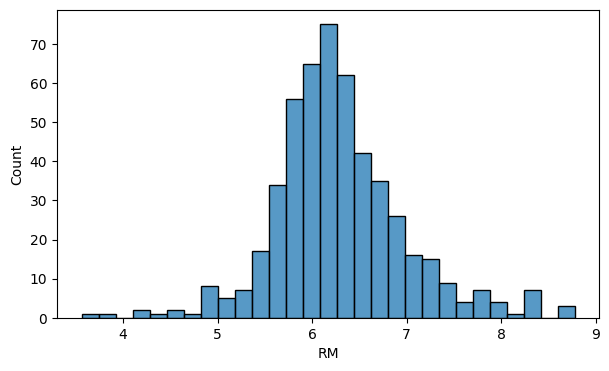

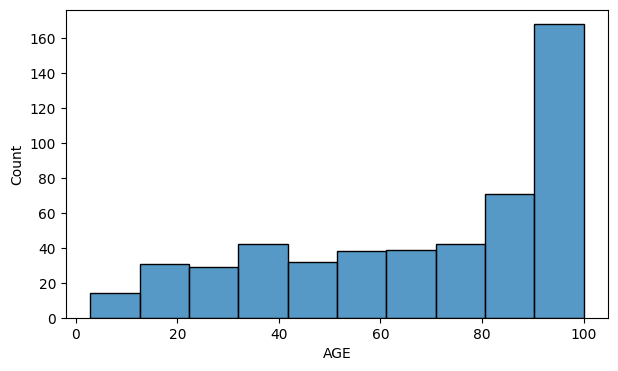

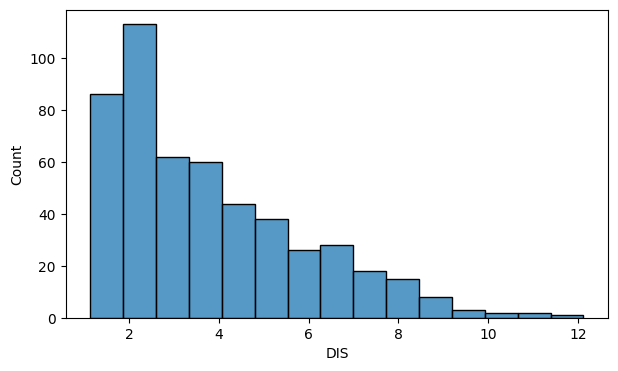

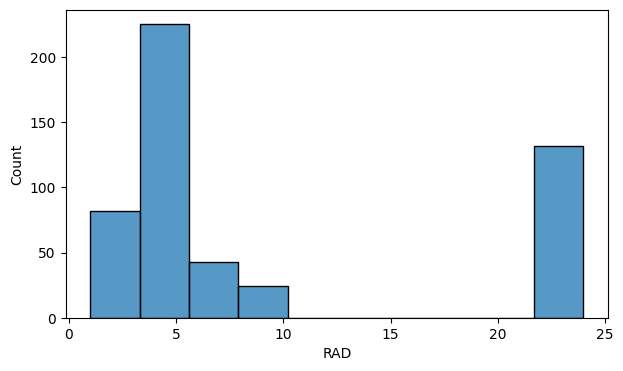

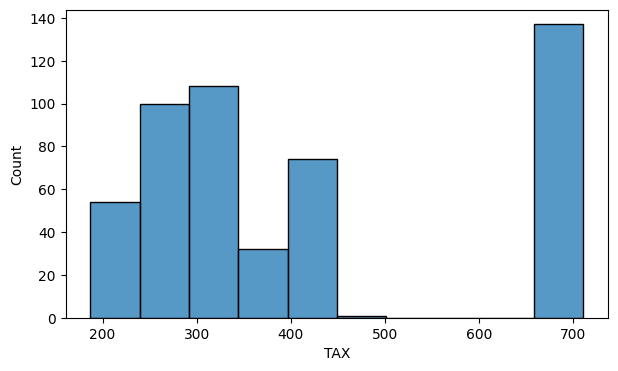

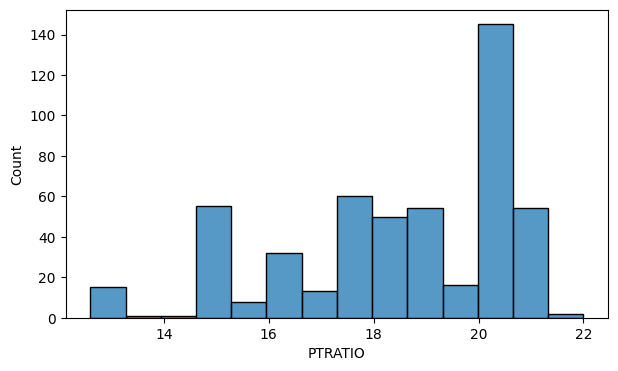

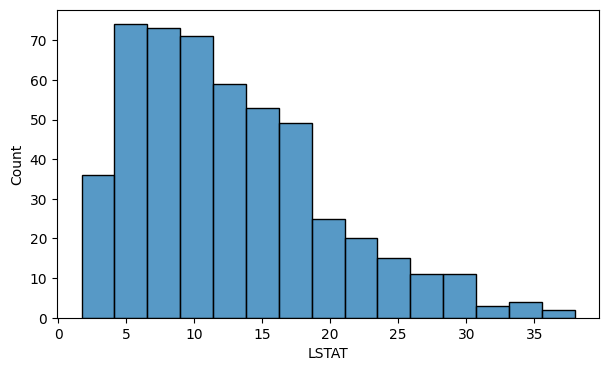

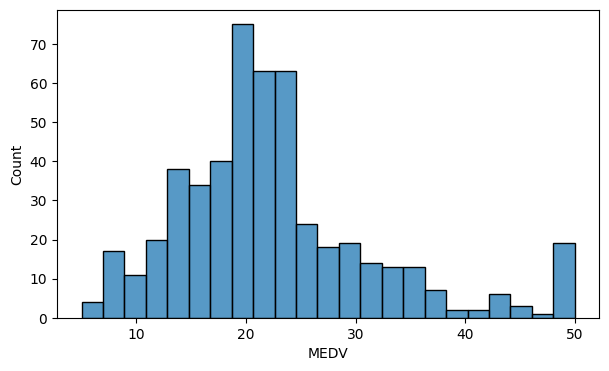

In [15]:
for i in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=i)
    plt.show()

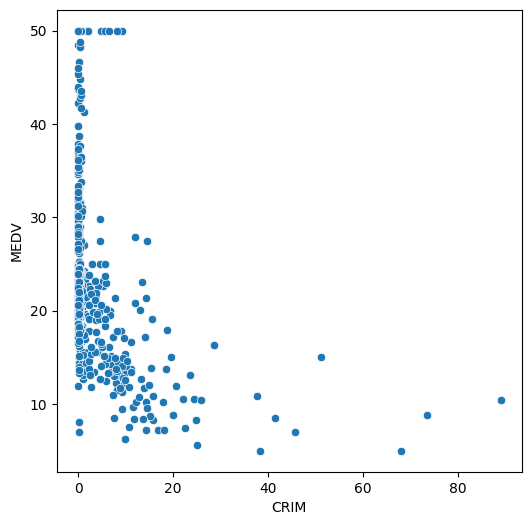

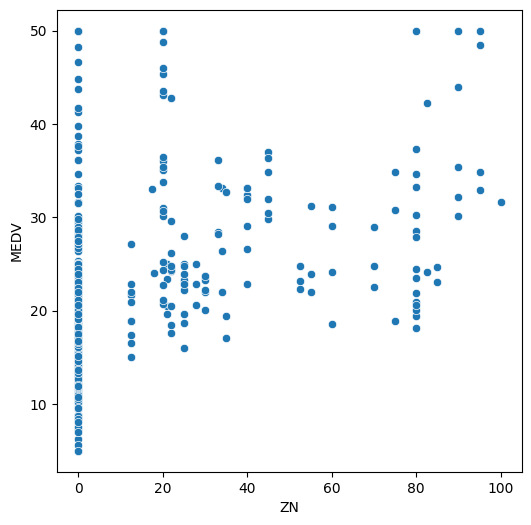

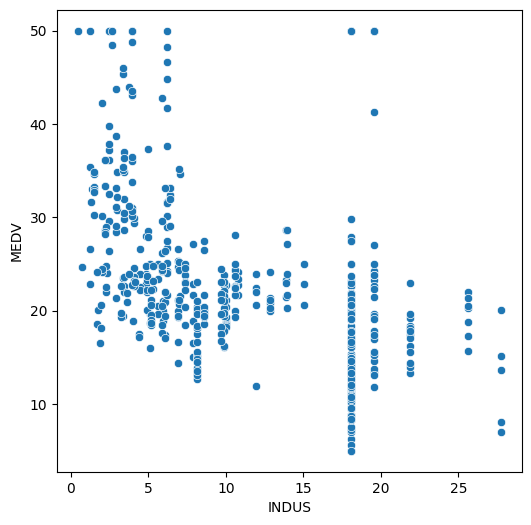

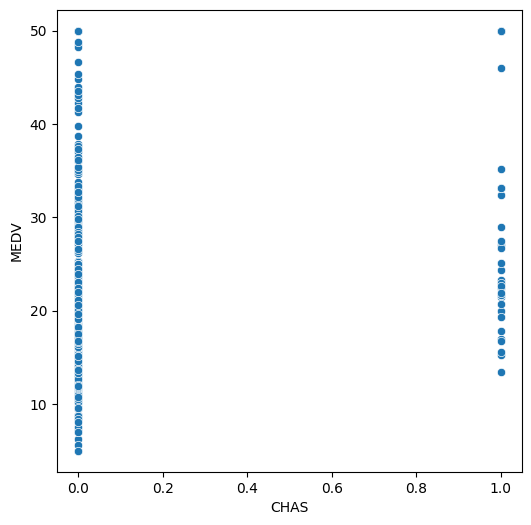

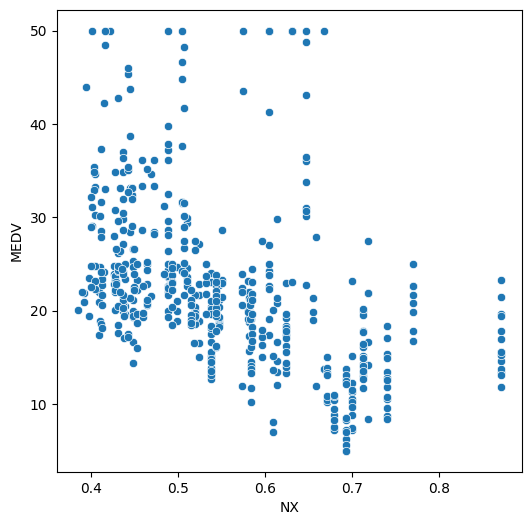

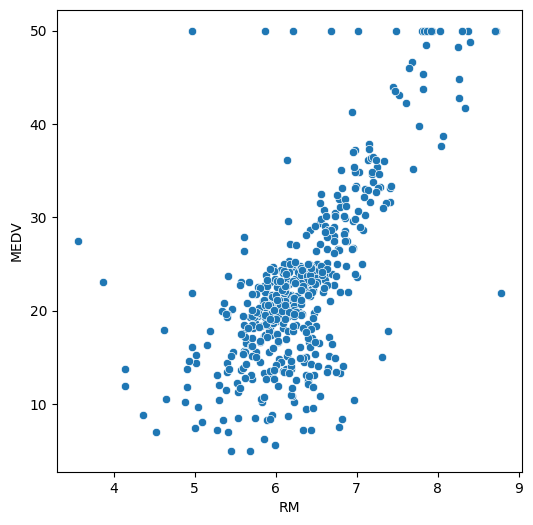

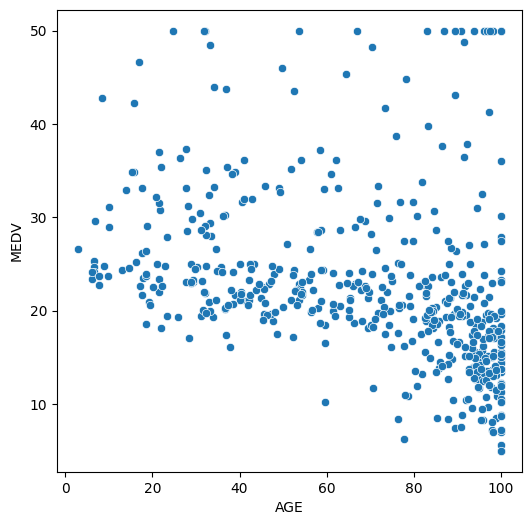

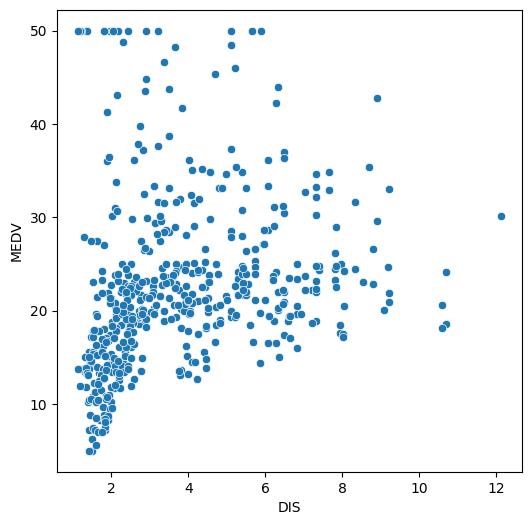

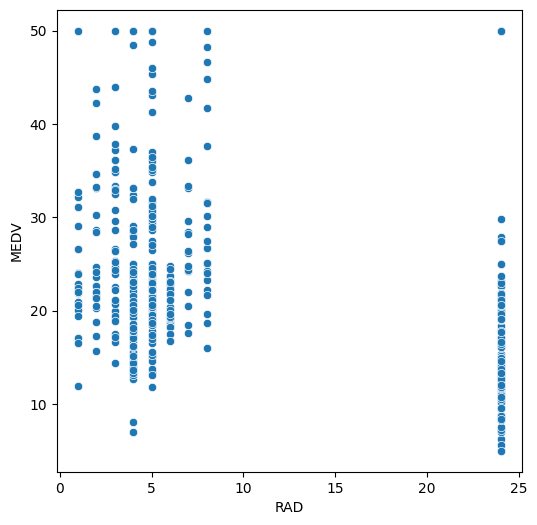

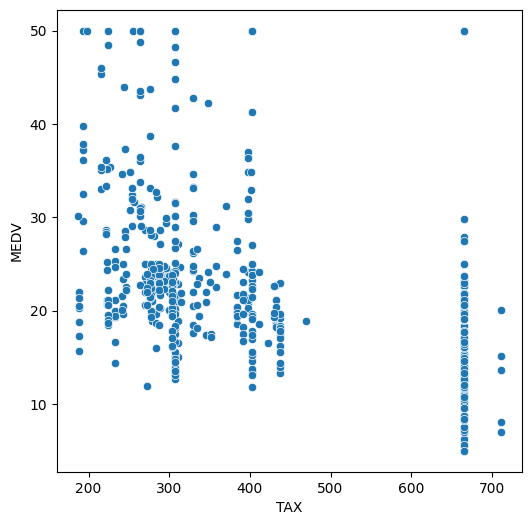

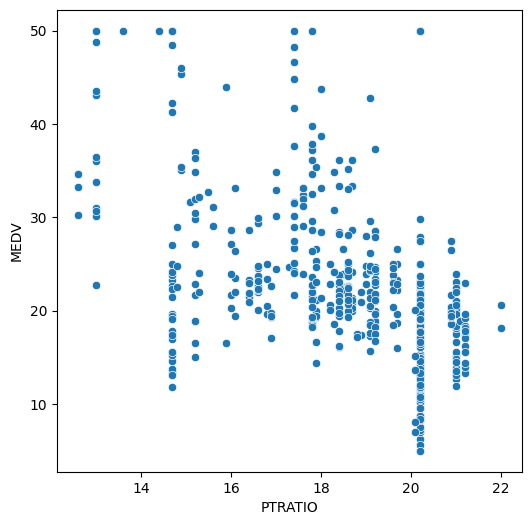

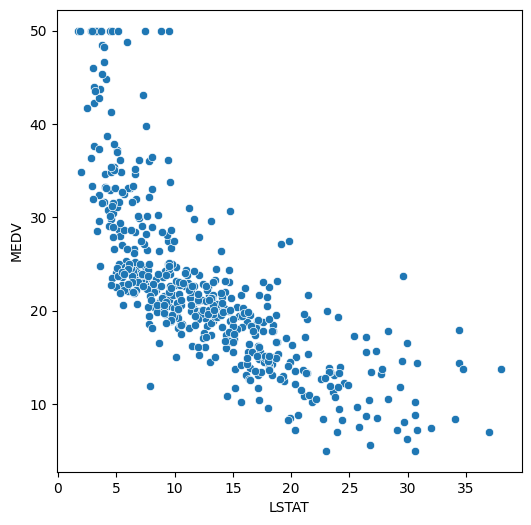

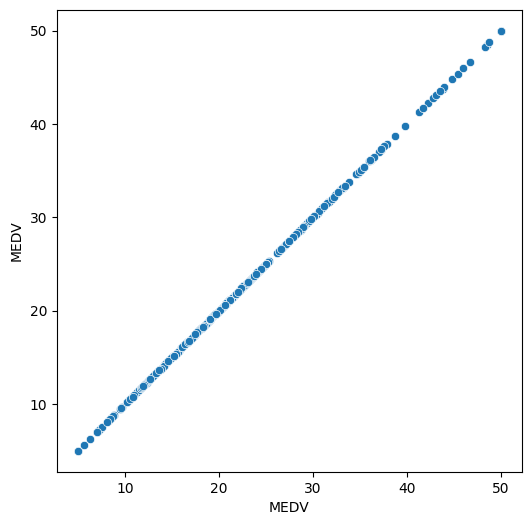

In [16]:
for i in df.columns:
    plt.figure(figsize=(6,6))
    sns.scatterplot(data=df, x=i, y="MEDV")
    plt.show()

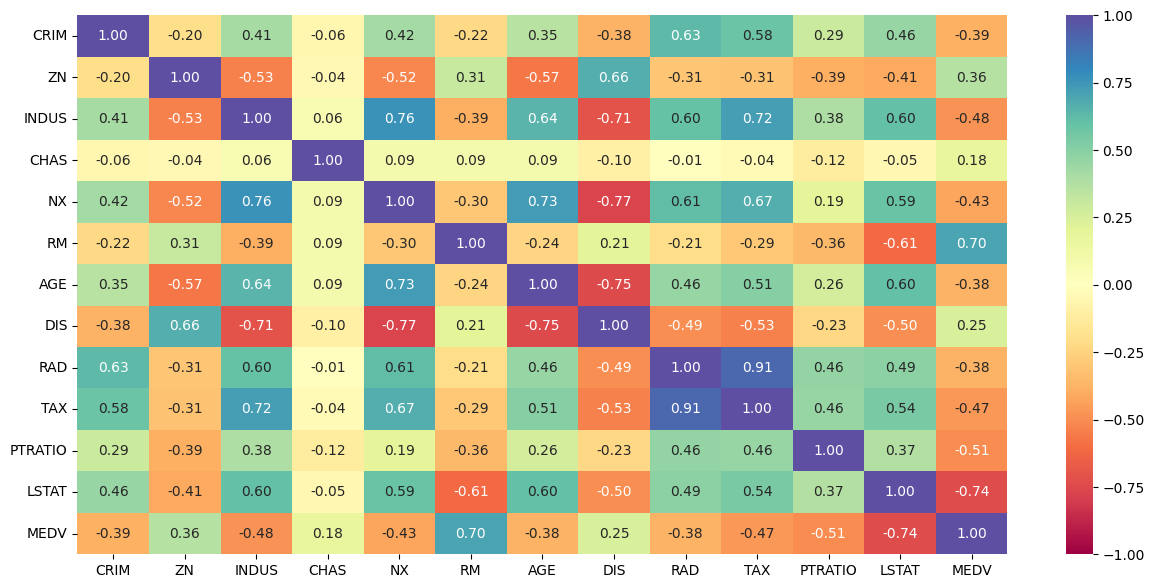

In [17]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

Split the dataset

In [19]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

Model Building

In [23]:
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

LinearRegression()

In [24]:
print("The score (R-squared) on the traning set is", regression_model.score(X_train, y_train))

The score (R-squared) on the traning set is 0.7073732058856179


In [26]:
def r_squared(model, X, y):
    y_mean = y.mean()
    SST = ((y - y_mean)**2).sum()
    SSE = ((y - model.predict(X))**2).sum()
    r_square = 1 - SSE/SST
    return SSE, SST, r_square

SSE, SST, r_square = r_squared(regression_model, X_train, y_train)
print("SSE: ", SSE)
print("SST: ", SST)
print("R-squared: ", r_square)



SSE:  8410.365734587129
SST:  28740.928389830508
R-squared:  0.7073732058856179


In [27]:
print(
    "The score (R-squared) on the test set is ", regression_model.score(X_test, y_test)
)

The score (R-squared) on the test set is  0.7721684899134136


Get the RMSE on train set

In [28]:
print(
    "The Root Mean Square Error (RMSE) of the model for the training set is ",
    np.sqrt(mean_squared_error(y_train, regression_model.predict(X_train))),
)

The Root Mean Square Error (RMSE) of the model for the training set is  4.874227661429436


Get the RMSE on test set

In [29]:
print(
    "The Root Mean Square Error (RMSE) of the model for the test set is ",
    np.sqrt(mean_squared_error(y_test, regression_model.predict(X_test))),
)

The Root Mean Square Error (RMSE) of the model for the test set is  4.569658652745824


Get the model coefficients.

In [30]:
coef_df = pd.DataFrame(
    np.append(regression_model.coef_, regression_model.intercept_),
    index=X_train.columns.tolist() + ["Intercept"],
    columns=["Coefficients"],
)

coef_df

,Coefficients
CRIM,-0.113845
ZN,0.061170
INDUS,0.054103
CHAS,2.517512
NX,-22.248502
RM,2.698413
AGE,0.004836
DIS,-1.534295
RAD,0.298833
TAX,-0.011414


In [31]:
Equation = "Price = " + str(regression_model.intercept_)
print(Equation, end=" ")

for i in range(len(X_train.columns)):
    if i != len(X_train.columns) - 1:
        print(
            "+ (",
            regression_model.coef_[i],
            ")*(",
            X_train.columns[i],
            ")",
            end="  ",
        )
    else:
        print("+ (", regression_model.coef_[i], ")*(", X_train.columns[i], ")")

Price = 49.88523466381736 + ( -0.11384484836914008 )*( CRIM )  + ( 0.06117026804060645 )*( ZN )  + ( 0.05410346495874601 )*( INDUS )  + ( 2.5175119591227144 )*( CHAS )  + ( -22.248502345084372 )*( NX )  + ( 2.6984128200099113 )*( RM )  + ( 0.004836047284751951 )*( AGE )  + ( -1.5342953819992557 )*( DIS )  + ( 0.29883325485901313 )*( RAD )  + ( -0.011413580552025043 )*( TAX )  + ( -0.9889146257039406 )*( PTRATIO )  + ( -0.5861328508499133 )*( LSTAT )
